In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}

In [3]:
from csv import writer
import pandas as pd
import numpy as np
import math

def segment(dataset, label, seg_size, overlap):
    myFile = open('trainData_Seg.csv', 'w', newline = '')
    print("Non-overlapping Region: %s" %overlap)
    print("Segment Size: %s" %seg_size)
    with myFile:
        csv_writer = writer(myFile)
        for j, row in enumerate(dataset):
            if(len(row) < 2001):
                pos = math.ceil(len(row)/overlap)
                if(pos < math.ceil(seg_size/overlap)):
                    pos = math.ceil(seg_size/overlap)
                for itr in range(pos - math.ceil(seg_size/overlap) + 1):
                    init = itr * overlap
                    segment = [ ]
                    if(len(row[init : init + seg_size]) > 40):
                        segment.append(row[init : init + seg_size])
                        for item in label[j]:
                            segment.append(item)
                        csv_writer.writerow(segment)
    myFile.close()

def main_fun(segSize, overLap):
  dataframe = pd.read_csv('/content/gdrive/MyDrive/DNA_RNA(GRU + M.Attn)/train_dataset.txt', header=None)
  dataset = dataframe.values
  print('Original Dataset Size : %s' %len(dataset))
  X = dataset[:,0]
  Y = dataset[:,1:len(dataset[0])]                  # 4-class problem

  DRBP_Y = np.sum(Y[:, 0:3], axis = -1)
  Y1 = np.column_stack((DRBP_Y, Y[:,3]))            # 2-class problem
  print("DRBP_Y= ",DRBP_Y)
  print("DRBP_Y= ",DRBP_Y.sum())
  print("Non_NABPs= ",Y1.sum()-DRBP_Y.sum())
  print("Y1= ",Y1)
  print("Y1= ",Y1.sum())
  segment(X, Y1, segSize, overLap)

In [4]:
import tensorflow as tf

class LiquidLayer(tf.keras.layers.Layer):
    def __init__(self, units, dt=0.1, return_sequences=True, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dt = dt
        self.return_sequences = return_sequences
        self.supports_masking = True

    def build(self, input_shape):
        self.input_dim = input_shape[-1]
        self.W = self.add_weight(shape=(self.units, self.units), initializer="glorot_uniform", trainable=True, name="W")
        self.U = self.add_weight(shape=(self.input_dim, self.units), initializer="glorot_uniform", trainable=True, name="U")
        self.b = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="b")

        # Learnable time constant (important!)
        self.tau = self.add_weight(shape=(self.units,), initializer=tf.keras.initializers.Constant(1.0), trainable=True, name="tau")

    def call(self, inputs, mask=None):
        """
        inputs: (batch, time, features)
        """
        batch_size = tf.shape(inputs)[0]
        x0 = tf.zeros((batch_size, self.units))

        # Time-major for tf.scan: (time, batch, features)
        inputs_tm = tf.transpose(inputs, [1, 0, 2])
        if mask is not None:
            mask_tm = tf.transpose(mask, [1, 0])  # (time, batch)

        def step(x, u_mask):
            u, m = u_mask
            dx = (-x + tf.nn.tanh(tf.matmul(x, self.W) +
                                  tf.matmul(u, self.U) +
                                  self.b)) / tf.clip_by_value(self.tau, 0.1, 10.0)

            x_next = x + self.dt * dx
            m = tf.cast(tf.expand_dims(m, -1), tf.float32)                      # 🔑 If masked timestep → keep previous state
            x_next = m * x_next + (1.0 - m) * x
            return x_next

        if mask is not None:
            states = tf.scan(step, (inputs_tm, mask_tm), initializer=x0)
        else:
            states = tf.scan(lambda x, u: x + self.dt * (-x + tf.nn.tanh(tf.matmul(x, self.W) + tf.matmul(u, self.U) + self.b)), inputs_tm, initializer=x0)

        # Back to batch-major: (batch, time, units)
        states = tf.transpose(states, [1, 0, 2])
        return states if self.return_sequences else states[:, -1, :]

    def compute_output_shape(self, input_shape):
        if self.return_sequences:
            return (input_shape[0], input_shape[1], self.units)
        else:
            return (input_shape[0], self.units)

In [5]:
import numpy as np
import math
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
np.random.seed(7)

def dictionary(chunk_size):
    dataframe = pd.read_csv("/content/gdrive/MyDrive/DNA_RNA(GRU + M.Attn)/train_dataset.txt", header=None)
    dataset = dataframe.values
    seq_dataset = dataset[:,0]
    print('Creating Dictionary:')
    dict = {}
    j = 0
    for row in seq_dataset:
        for i in range(len(row) - chunk_size + 1):
            key = row[i:i + chunk_size]
            if key not in dict:
                dict[key] = j
                j = j + 1
    del dataframe, dataset, seq_dataset
    return(dict)

def nGram(dataset, chunk_size, dictI):
    dict1 = list()
    for j, row in enumerate(dataset):
        string = row
        dict2 = list()
        for i in range(len(string) - chunk_size + 1):
            try:
                dict2.append(dictI[string[i:i + chunk_size]])
            except:
                None
        dict1.append(dict2)
    return(dict1)

def create_rec_model1(top_words, seq_len, o_dim):
    embedding_vecor_length = 8

    _input = layers.Input(shape=[seq_len])
    embdd = layers.Embedding(top_words, embedding_vecor_length, mask_zero=True)(_input)
    embdd = layers.GaussianNoise(0.05)(embdd)
    activations = LiquidLayer(128, dt=0.05)(embdd)
    #activations = layers.Bidirectional(layers.GRU(64, return_sequences=True))(drop)                   # GRU

    avg_pool = layers.GlobalAveragePooling1D()(activations)
    max_pool = layers.GlobalMaxPooling1D()(activations)

    activations = layers.Concatenate()([avg_pool, max_pool])

    drop1 = layers.Dropout(0.4)(activations)
    den1 = layers.Dense(64, kernel_initializer='normal', activation='relu')(drop1)

    drop2 = layers.Dropout(0.4)(den1)
    den2 = layers.Dense(32, kernel_initializer='normal', activation='relu')(drop2)

    drop3 = layers.Dropout(0.3)(den2)
    den = layers.Dense(o_dim, kernel_initializer='normal', activation='softmax', name='CLASSIFIER')(drop3)

    r_model = keras.Model(inputs = [_input], outputs = [den])

    opt = keras.optimizers.Adamax(learning_rate=0.0006)
    r_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return r_model

def class_weight(train_y):
    DRBP_Y = np.sum(train_y[:, 0], axis = -1)
    NonDRBP_Y = np.sum(train_y[:, 1], axis = -1)
    print(DRBP_Y, NonDRBP_Y)
    norm_DRBP_Y = NonDRBP_Y/(DRBP_Y + NonDRBP_Y)
    norm_NonDRBP_Y = DRBP_Y/(DRBP_Y + NonDRBP_Y)

    class_weight = {0: norm_DRBP_Y/norm_DRBP_Y, 1: (norm_NonDRBP_Y/norm_DRBP_Y)}
    return class_weight

# CREATING DICTIONARY
chunkSize = 4
dict_Prop = dictionary(chunkSize)

# Preparing For Training
segmentSize = 400
nonOL = 200
SEG = str(segmentSize)
main_fun(segmentSize, nonOL)                                       # Create segments
dataframe = pd.read_csv("trainData_Seg.csv", header=None)
dataset = dataframe.values

X = dataset[:,0]
Y = dataset[:,1:len(dataset[0])].astype(None)
nb_of_cls = len(Y[0])
del dataframe, dataset

class_weight = class_weight(Y)
print(class_weight)

#Split the dataset
x_train, x_validate, y_train, y_validate = train_test_split(X, Y, test_size = 0.1, random_state = 42)
del X, Y

#CREATING N-GRAM
x_train = nGram(x_train, chunkSize, dict_Prop)
x_validate = nGram(x_validate, chunkSize, dict_Prop)

# truncate and pad input sequences
max_seq_len = segmentSize - chunkSize + 1
x_train = keras.utils.pad_sequences(x_train, maxlen=max_seq_len)
x_validate = keras.utils.pad_sequences(x_validate, maxlen=max_seq_len)

# Create & Compile the model
model = create_rec_model1(len(dict_Prop), max_seq_len, nb_of_cls)
print(model.summary())
early_stopping_monitor1 = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 4, verbose = 1, restore_best_weights=True)
m_check = keras.callbacks.ModelCheckpoint(filepath = './gru_mattn_encoder.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1 )
history = model.fit(x_train, y_train,
          validation_data = (x_validate, y_validate),
          epochs = 1000,
          batch_size = 256,
          class_weight = class_weight,
          shuffle=True,
          callbacks=[m_check, early_stopping_monitor1],
          verbose=1)

Creating Dictionary:
Original Dataset Size : 10966
DRBP_Y=  [1 1 1 ... 0 0 0]
DRBP_Y=  6791
Non_NABPs=  4175
Y1=  [[1 0]
 [1 0]
 [1 0]
 ...
 [0 1]
 [0 1]
 [0 1]]
Y1=  10966
Non-overlapping Region: 200
Segment Size: 400
15186.0 7396.0
{0: np.float64(1.0), 1: np.float64(2.0532720389399675)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 397)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 397, 8)    │  1,265,568 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 397, 8)    │          0 │ embedding[0][0]   │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 397)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ liquid_layer        │ (None, 397, 128)  │     17,664 │ gaussian_noise[0… │
│ (LiquidLayer)       │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ liquid_layer[0][… │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ liquid_layer[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CLASSIFIER (Dense)  │ (None, 2)         │         66 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,301,826 (4.97 MB)

 Trainable params: 1,301,826 (4.97 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4057 - loss: 0.9365
Epoch 1: val_loss improved from inf to 0.68271, saving model to ./gru_mattn_encoder.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.4067 - loss: 0.9364 - val_accuracy: 0.6627 - val_loss: 0.6827
Epoch 2/1000
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5856 - loss: 0.9292
Epoch 2: val_loss improved from 0.68271 to 0.66554, saving model to ./gru_mattn_encoder.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5855 - loss: 0.9291 - val_accuracy: 0.6428 - val_loss: 0.6655
Epoch 3/1000
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6190 - loss: 0.9092
Epoch 3: val_loss improved from 0.66554 to 0.63911, saving model to ./gru_mattn_encoder.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6190 - loss: 0.9090 - val_accuracy: 0.6476 - val_loss: 0.6391
Epoch 4/1000
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6499 - loss: 0.8538
Epoch 4: val_loss 

In [6]:
from matplotlib import pyplot as plt
from keras import models
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, matthews_corrcoef, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, auc, recall_score

plt.rcParams.update({'font.size': 17})

def final_model(filename, overlap = 30):
    print('Extracting features based on LSTM model...... ')
    dataframe2 = pd.read_csv(filename, header=None)
    dataset2 = dataframe2.values
    X_test, Y_test = dataset2[:,0], dataset2[:,1:len(dataset2[0])]
    c_p = []
    for tag, row in enumerate(X_test):
        pos = math.ceil(len(row) / overlap)
        if(pos < math.ceil(segmentSize/ overlap)):
            pos = math.ceil(segmentSize/ overlap)
        segment = [ ]
        for itr in range(pos - math.ceil(segmentSize/overlap) + 1):
            init = itr * overlap
            segment.append(row[init : init + segmentSize])
        seg_nGram = nGram(segment, chunkSize, dict_Prop)
        test_seg = keras.utils.pad_sequences(seg_nGram, maxlen=max_seq_len)
        preds = model.predict(test_seg, verbose = 0)
        c_p.append(np.mean(preds, axis=0))
    c_p = np.array(c_p)
    return c_p, Y_test

def ratio_recall_curve(labels1, cross_label, scores):
    tpr, cro, thr = [], [], []
    for c in np.arange(1.0, -0.001, -0.0005):
        pred_labels = []
        for e in scores:
            if e >= c:
                pred_labels.append(1.0)
            else:
                pred_labels.append(0.0)
        tpr.append(recall_score(labels1, pred_labels))
        cro.append(recall_score(cross_label, pred_labels))
        thr.append(c)
    return tpr, cro, thr

def aurc_and_laurc_score(true_label, cross_label, tpred_scores11):
    tprs, cros, ths = ratio_recall_curve(true_label, cross_label, tpred_scores11)
    aurc = auc(tprs, cros)
    return aurc

# Creates a HDF5 file 'my_model.h5'
#model_path = '/content/gdrive/My Drive/DNA_RNA(B.Tech.)/GRU/Weighted/32.model_'+str(nonOL)+'_'+ SEG +'.h5'
#model.save(model_path)
#del model
#model = load_model(model_path)

# **TEST474 DATASET**

Extracting features based on LSTM model...... 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


(474, 2) (474, 4)
(474, 2) (474, 2)
(474,) (474,)
Confusion Matrix:  [[207  44]
 [ 55 168]]
MCC SCORE:  0.580292501070005
Recall: 78.90322119593375      Precision: 79.1264583033271      F1-score2: 78.97156684815488      Support: None
Recall: 79.11392405063292      Precision: 79.11392405063292      F1-score2: 79.11392405063292      Support: None


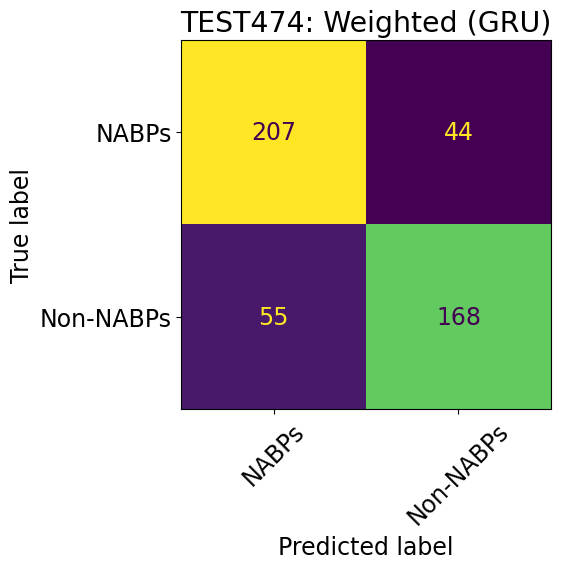

In [7]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)                        # Y_true.shape = 4

    DRBP_Y = np.sum(Y_true[:, 0:3], axis = -1)
    Y1 = np.column_stack((DRBP_Y, Y_true[:,3]))            # 2-class problem
    print(Y_Pred.shape, Y1.shape)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y1 = np.argmax(Y1, axis=1)
    print(Y_Pred.shape, Y1.shape)

    cm = confusion_matrix(Y1, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("TEST474: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y1, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y1, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y1, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/MyDrive/DNA_RNA(GRU + M.Attn)/Test_Folder/TEST474_test.txt")


# **DRBP206_test DATASET**

Extracting features based on LSTM model...... 
(206, 2) (206, 4)
(206,) (206,)
Confusion Matrix:  [[100   3]
 [ 61  42]]
MCC SCORE:  0.4581897949526569
Recall: 68.93203883495146      Precision: 77.72256728778468      F1-score2: 66.25716625716626      Support: None
Recall: 68.93203883495146      Precision: 68.93203883495146      F1-score2: 68.93203883495146      Support: None


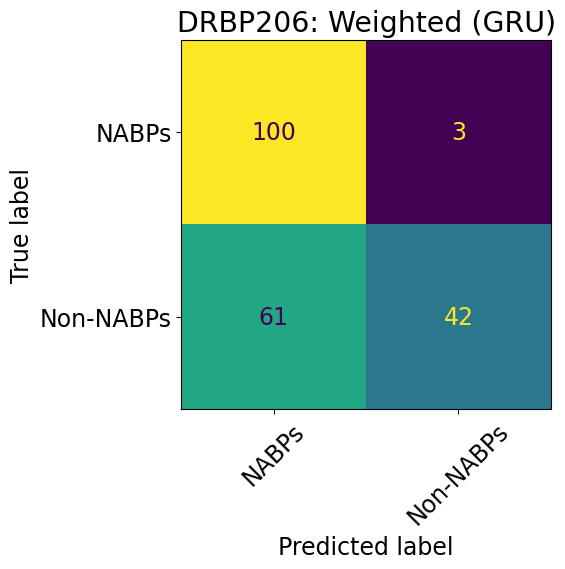

In [8]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)                 # (206, 2) (206, 4)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y_true = np.argmax(Y_true[:, 2:], axis=1)
    print(Y_Pred.shape, Y_true.shape)

    cm = confusion_matrix(Y_true, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("DRBP206: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y_true, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/MyDrive/DNA_RNA(GRU + M.Attn)/Test_Folder/DRBP206_test.txt")

# **PDB255_test DATASET**

Extracting features based on LSTM model...... 
(255, 2) (255, 4)
(255, 2) (255, 2)
(255,) (255,)
Confusion Matrix:  [[74 89]
 [34 58]]
MCC SCORE:  0.08204940663876295
Recall: 54.22112563350227      Precision: 53.98715041572184      F1-score2: 51.57405548950887      Support: None
Recall: 51.76470588235295      Precision: 51.76470588235295      F1-score2: 51.76470588235295      Support: None


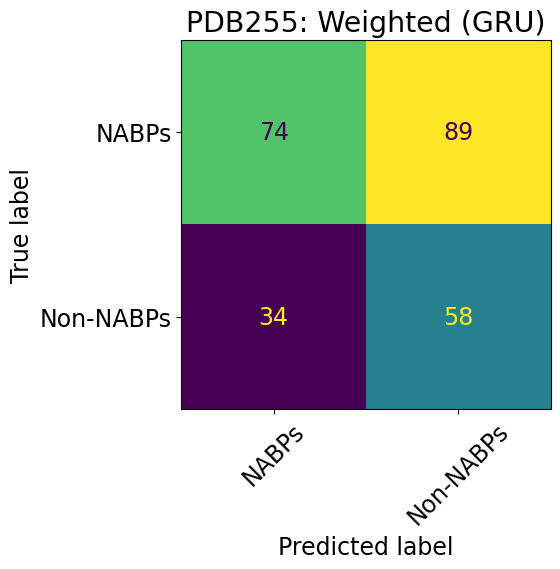

In [9]:
# label_dict = {'DNA': 0,             'RNA': 1,              'DNA and RNA': 2,               'DNA nor RNA': 3}
# Testing
def test_fun(file):
    Y_Pred, Y_true = final_model(file)
    print(Y_Pred.shape, Y_true.shape)

    DRBP_Y = np.sum(Y_true[:, 0:2], axis = -1)
    Y1 = np.column_stack((DRBP_Y, Y_true[:,3]))            # 2-class problem
    print(Y_Pred.shape, Y1.shape)

    Y_Pred = np.argmax(Y_Pred, axis=1)
    Y_true = np.argmax(Y1, axis=1)
    print(Y_Pred.shape, Y_true.shape)

    cm = confusion_matrix(Y_true, Y_Pred)
    print("Confusion Matrix: ", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NABPs", "Non-NABPs"])
    disp.plot(xticks_rotation=45, colorbar = False)
    disp.ax_.set_title("PDB255: Weighted (GRU)")

    print("MCC SCORE: ", matthews_corrcoef(Y_true, Y_Pred))

    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='macro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))
    pre, rec, f1, sup = precision_recall_fscore_support(Y_true, Y_Pred, average='micro')
    print('Recall: {0}'.format(rec*100), '     Precision: {0}'.format(pre*100), '     F1-score2: {0}'.format(f1*100), '     Support: {0}'.format(sup))

    return None

th_set = test_fun("/content/gdrive/MyDrive/DNA_RNA(GRU + M.Attn)/Test_Folder/PDB255_test.txt")